In [162]:
import time
import os
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
import corner
from scipy import optimize
from simple_pe.param_est.pe import SimplePESamples
from simple_pe.param_est.filter import matched_filter_network
from simple_pe.waveforms import waveform, waveform_modes, eccentric
from simple_pe import io
from pesummary.io import read
from pesummary.utils.samples_dict import SamplesDict
from pesummary.gw.conversions.mass import q_from_eta, component_masses_from_mchirp_q

import logging
_logger = logging.getLogger('PESummary')
_logger.setLevel(logging.CRITICAL + 10)
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [161]:
# Load run files
dir_path = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_1/outdir/output'
inj_path = os.path.join(dir_path, 'converted_injection_parameters.json')
with open(inj_path, 'r') as f:
    all_inj_params = json.load(f)
peak_path = os.path.join(dir_path, 'peak_parameters.json')
with open(peak_path, 'r') as f:
    all_peak_params = json.load(f)
metric_path = os.path.join(dir_path, 'filter_metric.pkl')
with open(metric_path, 'rb') as f:
    metric = pickle.load(f)
samples_path = os.path.join(dir_path, 'posterior_samples.dat')
samples = SimplePESamples(read(samples_path).samples_dict)

# Load psds
asds = {'H1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/aligo_O4high.txt',
        'L1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/aligo_O4high.txt',
        'V1':'/home/ben.patterson/projects/simple-pe/examples/zero-noise/avirgo_O4high_NEW.txt'}
psds = io.load_psd_from_file([], asds, 1/32, 15, 2048)

# Load data
trig_path = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_1/trigger_parameters.json'
strain_paths = {'H1': os.path.join(dir_path, 'H1-INJECTION.gwf'),
                'L1': os.path.join(dir_path, 'L1-INJECTION.gwf'),
                'V1': os.path.join(dir_path, 'V1-INJECTION.gwf')}
trigger_parameters = io.load_trigger_parameters_from_file(trig_path, 'TEOBResumS-Dali')
_, data = io.load_strain_data_from_file(
    trigger_parameters, strain_paths, {'H1':'HWINJ_INJECTED', 'L1':'HWINJ_INJECTED', 'V1':'HWINJ_INJECTED'}, 10,
    2048, minimum_data_length=32
)

If we use dx coordinates of the metric, can we optimise over each direction independently once we are close to the peak? Let's see first how different this is for the metric calculated at the peak non-eccentric point (filter_metric) and the current final peak eccentric point (analysis_metric).

One challenge here is that each metric has an infinite number of sets of orthogonal vectors, of which the dx coordinates are just an arbitrary choice in each case, so we cannot simply compare the eigenvectors of each metric. Instead I will convert eigenvectors of the filter metric into the dx space of the analysis metric and measure orthogonality.

In [84]:
params = ['ecc10sqrd', 'chirp_mass', 'symmetric_mass_ratio', 'chi_align']
fparams_args = []
aparams_args = []
for par in params:
    fparams_args.append(filter_metric.dx_directions.index(par))
    aparams_args.append(analysis_metric.dx_directions.index(par))
test = np.matmul(np.linalg.inv(analysis_metric.normalized_evecs().samples[aparams_args]), filter_metric.normalized_evecs().samples[fparams_args])
for i in range(len(test)):
    for j in range(i):
        print(i, j, np.dot(test[i], test[j])/(np.sqrt(np.dot(test[i], test[i])*np.dot(test[j], test[j]))))

1 0 -0.6417670363664493
2 0 -0.18028802339590733
2 1 0.5821556626553223
3 0 -0.30213647045646363
3 1 0.3989024249741506
3 2 0.03582197157470001


It is clear that these are not very orthogonal. We therefore cannot just use the metric calculated at the non-eccentric peak as an approximation of the metric at the peak of the degeneracy line. Instead plan to use zeroth iteration to calculate metric at non-eccentric peak point, and then perform another iteration at the peak of the degeneracy line using the eigenvectors of the first metric as a starting point.

For this proof of concept study will simply use the eigenvectors of the analysis metric which should be quite accurate.

In fact, find that Powell method of scipy.optimize.minimize already implements this idea of optimizing in 1d directions sequentially, so we can simply use that.

In [131]:
def _neg_net_snr_extra(
    scaling, evec, ifos, data, psds, t_start, t_end, f_low, approximant,
    ecc_harms, metric, maxs=None, mins=None, fixed_pars=None, harm2=False, verbose=False
):

    # Check in bounds
    alpha = waveform.check_physical(metric.x, evec, scaling, maxs=maxs, mins=mins)
    if alpha < 1:
        return 0
    params = [scaling*evec[dx][0] + metric.x[dx][0] for dx in metric.dx_directions]
    
    s = dict(zip(metric.dx_directions, params))
    if fixed_pars is not None:
        s.update(fixed_pars)

    if verbose:
        print(f'making waveform with scaling {scaling[0]:.3f} at parameters')
        print(s)
    try:
        z_ecc = {}
        modes = [0, 1, -1]
        for ifo in ifos:
            z_ecc[ifo], _ = waveform_modes.calculate_mode_snr(
                data[ifo], psds[ifo], ecc_harms[ifo], t_start, t_end, f_low, modes,
                subsample_interpolation=True, dominant_mode=0
            )
        _, mode_snrs = waveform_modes.network_mode_snr(
            z_ecc, ifos, modes, dominant_mode=0, return_cplx=True
        )
        _, target_ma = waveform_modes.two_ecc_harms_snr(
            {k: np.abs(mode_snrs[k]) for k in [0, 1, -1]},
            {k: np.angle(mode_snrs[k]) for k in [0, 1, -1]}
        )
        q = q_from_eta(s['symmetric_mass_ratio'])
        m_total = np.sum(component_masses_from_mchirp_q(s['chirp_mass'], q))
    
        harm_psd = io.calculate_harmonic_mean_psd(psds)
        h = eccentric.generate_eccentric_waveform_ma(
            m_total, q,
            s['ecc10sqrd']**0.5, s['chi_align'],
            s['chi_align'], harm_psd, f_low, target_ma, ecc_harms['harm'],
            align_merger=True, to_fs=True
        )

    except RuntimeError:
        print('error making waveform')
        return np.inf

    s = matched_filter_network(
        ifos, data, psds, t_start, t_end, h, f_low,
        subsample_interpolation=True
    )[0]

    if verbose:
        print('snr = %.4f' % s)

    return -s

In [139]:
def _neg_net_snr_extra(
    x, ifos, data, psds, t_start, t_end, f_low, approximant,
    ecc_harms, metric, maxs=None, mins=None, fixed_pars=None, harm2=False, verbose=False
):

    # Check in bounds
    delta_params_list = np.matmul(metric.normalized_evecs().samples, x)
    delta_params = SimplePESamples(SamplesDict(metric.dx_directions, [[param] for param in delta_params_list]))
    alpha = waveform.check_physical(metric.x, delta_params, 1, maxs=maxs, mins=mins)
    if alpha < 1:
        return 0
    params = [delta_params[dx][0] + metric.x[dx][0] for dx in metric.dx_directions]
    
    s = dict(zip(metric.dx_directions, params))
    if fixed_pars is not None:
        s.update(fixed_pars)

    if verbose:
        print(f'making waveform with dx coords {x} at parameters')
        print(s)
    try:
        z_ecc = {}
        modes = [0, 1, -1]
        for ifo in ifos:
            z_ecc[ifo], _ = waveform_modes.calculate_mode_snr(
                data[ifo], psds[ifo], ecc_harms[ifo], t_start, t_end, f_low, modes,
                subsample_interpolation=True, dominant_mode=0
            )
        _, mode_snrs = waveform_modes.network_mode_snr(
            z_ecc, ifos, modes, dominant_mode=0, return_cplx=True
        )
        _, target_ma = waveform_modes.two_ecc_harms_snr(
            {k: np.abs(mode_snrs[k]) for k in [0, 1, -1]},
            {k: np.angle(mode_snrs[k]) for k in [0, 1, -1]}
        )
        q = q_from_eta(s['symmetric_mass_ratio'])
        m_total = np.sum(component_masses_from_mchirp_q(s['chirp_mass'], q))
    
        harm_psd = io.calculate_harmonic_mean_psd(psds)
        h = eccentric.generate_eccentric_waveform_ma(
            m_total, q,
            s['ecc10sqrd']**0.5, s['chi_align'],
            s['chi_align'], harm_psd, f_low, target_ma, ecc_harms['harm'],
            align_merger=True, to_fs=True
        )

    except RuntimeError:
        print('error making waveform')
        return np.inf

    s = matched_filter_network(
        ifos, data, psds, t_start, t_end, h, f_low,
        subsample_interpolation=True
    )[0]

    if verbose:
        print('snr = %.4f' % s)

    return -s

In [94]:
# Set up
ifos = list(psds.keys())
t_start = trigger_parameters['time']-0.1
t_end = trigger_parameters['time']+0.1
dx_directions = ['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10sqrd']
fixed_pars = {}

# Create eccentric harmonics
params = {key: all_peak_params['posterior_samples'][key] for key in dx_directions}
ecc_harm_psds = psds.copy()
ecc_harm_psds['harm'] = io.calculate_harmonic_mean_psd(psds)
ecc_harms = waveform.make_waveform(params, psds[ifos[0]].delta_f, 20, len(psds[ifos[0]]), 'TEOBResumS-Dali-Harms', n_ecc_gen=6, n_ecc_harms=3, ecc_harm_psd=ecc_harm_psds)

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


In [153]:
# Perform optimisation using scipy.optimize.minimize
start = time.time()
out = optimize.minimize(
    _neg_net_snr_extra, [0, 0, 0, 0], args=(
    ifos, data, psds, t_start, t_end,
    20, 'TEOBResumS-Dali', ecc_harms, analysis_metric, None, None, fixed_pars, False, True
    ), bounds=[(-1,1)], method='Powell', options={'maxiter': 1, 'direc': np.identity(4), 'xtol': 0.1, 'ftol': np.inf}
)
end = time.time()
print(f'{end-start:.2f} seconds')
print(f'SNR: {-out.fun:.4f}, nfev: {out.nfev}')
print(out.x)

making waveform with dx coords [0. 0. 0. 0.] at parameters
{'chirp_mass': 30.30046706834873, 'symmetric_mass_ratio': 0.2372086717564731, 'chi_align': 0.09050120667666045, 'ecc10sqrd': 0.016855374011666882}
snr = 20.4818
making waveform with dx coords [-0.23606798  0.          0.          0.        ] at parameters
{'chirp_mass': 30.30051429575404, 'symmetric_mass_ratio': 0.23545904286460906, 'chi_align': 0.09003619651167936, 'ecc10sqrd': 0.017237044672824765}
snr = 20.4986
making waveform with dx coords [0.23606798 0.         0.         0.        ] at parameters
{'chirp_mass': 30.30041984094342, 'symmetric_mass_ratio': 0.23895830064833712, 'chi_align': 0.09096621684164154, 'ecc10sqrd': 0.016473703350509}
snr = 20.4576
making waveform with dx coords [-0.52786405  0.          0.          0.        ] at parameters
{'chirp_mass': 30.300572672037404, 'symmetric_mass_ratio': 0.23329638261886748, 'chi_align': 0.08946141233753435, 'ecc10sqrd': 0.017708815555033196}
snr = 20.5072
making waveform

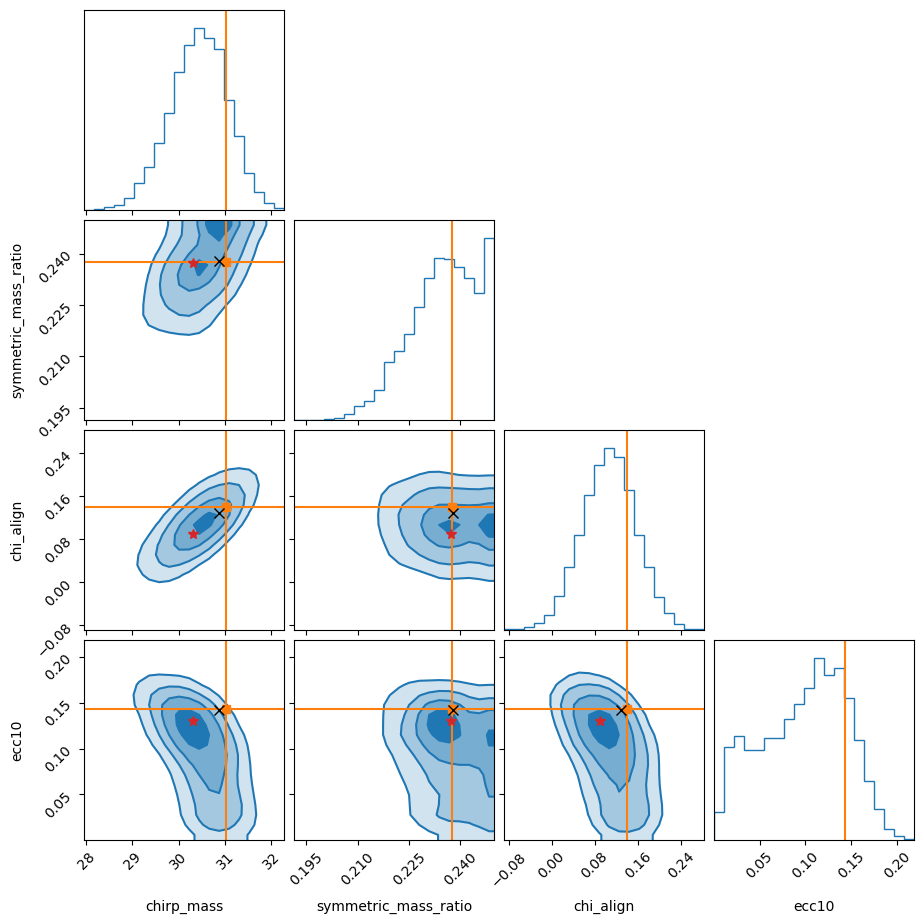

In [193]:
params = ['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10']
corner_samples = np.array([samples[key] for key in params]).T
corner_truths = [all_inj_params['posterior_samples'][par][0] for par in params]
fig = corner.corner(corner_samples, truths=corner_truths, color='C0', truth_color='C1', smooth=1, labels=params, plot_density=False, plot_datapoints=False, fill_contours=True)
old_params = [all_peak_params['posterior_samples'][par][0] for par in params]
corner.overplot_points(fig, [old_params], c='C3', label='old peak', marker='*', markersize=7)
delta_params_list = np.matmul(analysis_metric.normalized_evecs().samples, out.x)
delta_params = SimplePESamples(SamplesDict(analysis_metric.dx_directions, [[param] for param in delta_params_list]))
new_params = [delta_params[dx][0] + analysis_metric.x[dx][0] for dx in ['chirp_mass', 'symmetric_mass_ratio', 'chi_align', 'ecc10sqrd']]
new_params[-1] = np.sqrt(new_params[-1])
corner.overplot_points(fig, [new_params], c='k', label='new peak', marker='x', markersize=7)

In [204]:
all_inj_params['posterior_samples']['ecc10sqrd'] = [all_inj_params['posterior_samples']['ecc10'][0]**2]
inj_params_diff_old = [all_inj_params['posterior_samples'][par][0] - all_peak_params['posterior_samples'][par][0] for par in analysis_metric.dx_directions]
inj_dx_diff_old = np.matmul(np.linalg.inv(analysis_metric.normalized_evecs().samples), inj_params_diff_old)
dx_dist_old = np.sqrt(np.dot(inj_dx_diff_old, inj_dx_diff_old))
inj_dx_diff_new = np.array(inj_dx_diff_old) - np.array(out.x)
dx_dist_new = np.sqrt(np.dot(inj_dx_diff_new, inj_dx_diff_new))
print(f'Reduced dx distance from {dx_dist_old:.3f} to {dx_dist_new:.3f}')

Reduced dx distance from 0.970 to 0.189
